# Data Analysis Process

1. Data Wrangling<br>
    a. Assessing Data<br>
    b. Cleaning Data
2. Exploratory Data Analysis
3. Drawing Conclusion

## 1. Data Wrangling

- `Dirty Data (Data with Quality issues)`: Dirty data, also known as low quality data. Low quality data has content issues.
  - Duplicated data
  - Missing Data
  - Corrupt Data
  - Inaccurate Data
- `Messy Data (Data with tidiness issues)`: Messy data, also known as untidy data. Untidy data has structural issues.Tidy data has the following properties:

  - Each variable forms a column
  - Each observation forms a row
  - Each observational unit forms a table

#### Loading Data

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import warnings
warnings.filterwarnings('ignore')

In [3]:
operational_metrics = pd.read_csv('/content/drive/MyDrive/Data/operational_metrics.csv')
seismic_events = pd.read_csv('/content/drive/MyDrive/Data/seismic_events.csv')

### 1. Data Summary

In [4]:
operational_metrics.head()

,recorded_at,phase,inj_flow,inj_whp,inj_temp,inj_ap,prod_temp,prod_whp,gt03_whp,hedh_thpwr,...,phase_production_ended_at,phase_ended_at,volume,cum_volume,inj_energy,cum_inj_energy,cooling_energy,cum_cooling_energy,heat_exch_energy,cum_heat_exch_energy
0,2018-11-28 11:20:00,0.0,3.473958,29.742170,18.670664,0.0,22.161097,5.309335,0.0,NaN,...,2018-11-28 14:15:00,2018-12-04 12:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN
1,2018-11-28 11:25:00,0.0,25.510803,29.709707,11.027036,0.0,22.115342,5.307418,0.0,NaN,...,2018-11-28 14:15:00,2018-12-04 12:00:00,2.125900,2.125900,0.001754,0.001754,0.306809,0.306809,NaN,NaN
2,2018-11-28 11:30:00,0.0,1.215181,29.675275,10.577293,0.0,22.089825,5.306586,0.0,NaN,...,2018-11-28 14:15:00,2018-12-04 12:00:00,0.101265,2.227165,0.000083,0.001838,0.014663,0.321472,NaN,NaN
3,2018-11-28 11:35:00,0.0,8.490693,29.644622,10.619303,0.0,22.057563,5.306062,0.0,NaN,...,2018-11-28 14:15:00,2018-12-04 12:00:00,0.707558,2.934723,0.000583,0.002421,0.102423,0.423895,NaN,NaN
4,2018-11-28 11:40:00,0.0,0.057919,29.614782,10.622052,0.0,22.148908,5.306007,0.0,NaN,...,2018-11-28 14:15:00,2018-12-04 12:00:00,0.004827,2.939550,0.000004,0.002425,0.000699,0.424594,NaN,NaN


In [5]:
seismic_events.head()

,occurred_at,event_id,phase,is_producing,phase_started_at,phase_production_ended_at,phase_ended_at,location,pgv_max,magnitude,hourly_seismicity_rate,distance_to_fault,x,y,z
0,2018-12-05 05:29:53.740,3,0.01,True,2018-12-04 12:00:00,2018-12-11 12:29:00,2018-12-11 12:30:00,POINT Z (201946.428571 214650 -3815.47619),0.013925,0.197000,0,1255.751385,201946.428571,214650.0,-3815.476190
1,2018-12-06 12:18:08.140,9,0.01,True,2018-12-04 12:00:00,2018-12-11 12:29:00,2018-12-11 12:30:00,POINT Z (202005.952381 214650 -3815.47619),0.017326,0.396200,0,1206.415505,202005.952381,214650.0,-3815.476190
2,2018-12-07 07:03:55.513,14,0.01,True,2018-12-04 12:00:00,2018-12-11 12:29:00,2018-12-11 12:30:00,POINT Z (202125 214230 -4053.571429),0.009658,-0.002200,0,1365.234569,202125.000000,214230.0,-4053.571429
3,2018-12-07 07:04:08.897,15,0.01,True,2018-12-04 12:00:00,2018-12-11 12:29:00,2018-12-11 12:30:00,POINT Z (202125 214170 -3577.380952),0.011502,0.068001,0,1192.798298,202125.000000,214170.0,-3577.380952
4,2018-12-07 07:04:17.413,16,0.01,True,2018-12-04 12:00:00,2018-12-11 12:29:00,2018-12-11 12:30:00,POINT Z (202184.52381 214050 -3755.952381),0.013325,-0.101800,0,1262.362209,202184.523810,214050.0,-3755.952381


In [6]:
operational_metrics.shape

(695625, 25)

In [7]:
seismic_events.shape

(378, 15)

These data files came from the Balmatt Geothermal Plant in Mol, Belgium, run by VITO. It tracks how the plant produces heat from deep underground and how those operations sometimes link to small nearby earthquakes. We have two data files, named as `operational data` and `seismic data`.

The `operational data` contains over 690,000 observations collected at 5-minute intervals from late 2018 to 2025. This dataset covers multiple operational features, It includes variables such as injection flow, wellhead pressure, temperature, energy, and volume, with timestamps marking the start, end, and production periods of each phase.

The `seismic dataset` lists 378 events with their occurrence time, magnitude, peak ground velocity, depth, and coordinates, along with the corresponding operational phase.

### 2. Column's Description

#### **Table:** `operational_metrics`

- **`Recorded_a`**: Timestamp of each observation.  
- **`Phase`**: The operational phase identifier.  
- **`Inj_flow`**: Total injection flow rate [m³/h].  
- **`Inj_whp`**: Injection Wellhead Pressure [bar].  
- **`Inj_temp`**: Injection Wellhead Temperature [°C].  
- **`Inj_ap`**: Injection Annular Pressure [bar].  
- **`Prod_temp`**: Production Wellhead Temperature [°C].  
- **`Prod_whp`**: Production Wellhead Pressure [bar].  
- **`Gt03_whp`**: Wellhead Pressure [bar] in the GT03 well (GT03 is a different well from the production wells).  
- **`hedh_thpwr`**: Thermal power of the heat exchanger on the district heating side [kW].  
- **`basin_flow`**: Basin injection flow rate [m³/h].  
- **`prod_flow`**: Production flow rate [m³/h] — calculated as `inj_flow - basin_flow`.  
- **`is_producing`**: Boolean flag indicating whether the plant is producing energy (`TRUE` = producing, `FALSE` = idle).  
- **`phase_started_at`**: Timestamp marking the start of the operational phase.  
- **`phase_production_ended_at`**: Timestamp marking when production ended within this operational phase.  
- **`Phase_ended_at`**: Timestamp marking the end of the operational phase.  
- **`volume`**: Injected volume [m³].  
- **`cum_volume`**: Cumulative injected volume within this phase [m³].  
- **`inj_energy`**: Injected Energy [MWh], calculated as the product of injected volume and injection pressure.  
- **`cum_inj_energy`**: Cumulative Injected Energy within this phase [MWh].  
- **`cooling_energy`**: Energy extracted from the brine before reinjection [MWh]. Calculated as the enthalpy difference of brine at reservoir vs. injection conditions (assuming no temperature gain in the injection well). The estimated error is about 5–10%.  
- **`cum_cooling_energy`**: Cumulative Extracted (Cooling) Energy of this phase [MWh].  
- **`heat_exch_energy`**: Heat Exchanger Energy [MWh].  
- **`cum_heat_exch_energy`**: Cumulative Heat Exchanger Energy of this phase [MWh].


#### **Table:** `seismic_events`

- **`occurred_at`**: Timestamp of the seismic event.  
- **`event_id`**: Unique identifier of the seismic event.  
- **`phase`**: Operational phase during which the event occurred.  
- **`is_producing`**: Boolean flag indicating whether the plant was producing during the event (`TRUE` = producing, `FALSE` = idle).  
- **`phase_started_at`**: Timestamp marking the start of the operational phase.  
- **`phase_production_ended_at`**: Timestamp marking the end of production within this operational phase.  
- **`phase_ended_at`**: Timestamp marking the end of the operational phase.  
- **`pgv_max`**: Maximum peak ground velocity [m/s] — the highest horizontal velocity of the ground during the quake.  
- **`magnitude`**: Local magnitude of the seismic event.  
- **`Hourly_seismicity_rate`**: Number of events with a local magnitude > 0.5 occurring in the last hour.  
- **`Distance_to_fault`**: Distance of the epicenter from the nearest seismic fault [m or km].  
- **`Location`**: Coordinates of the epicenter in EPSG:31370 (Lambert 72) coordinate system.  
- **`x`**: X-coordinate of the epicenter (easting).  
- **`y`**: Y-coordinate of the epicenter (northing).  
- **`z`**: Z-coordinate of the epicenter (depth).  

### Issues with the dataset

In [9]:
operational_metrics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 695625 entries, 0 to 695624
Data columns (total 25 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   recorded_at                695625 non-null  object 
 1   phase                      695625 non-null  float64
 2   inj_flow                   695278 non-null  float64
 3   inj_whp                    689533 non-null  float64
 4   inj_temp                   689492 non-null  float64
 5   inj_ap                     682699 non-null  float64
 6   prod_temp                  689494 non-null  float64
 7   prod_whp                   689538 non-null  float64
 8   gt03_whp                   695343 non-null  float64
 9   hedh_thpwr                 654494 non-null  float64
 10  basin_flow                 683659 non-null  float64
 11  prod_flow                  683344 non-null  float64
 12  source                     695625 non-null  object 
 13  is_producing               69

In [10]:
operational_metrics["phase"].unique()

array([0.00e+00, 1.00e-02, 2.00e-02, 3.00e-02, 4.00e-02, 5.00e-02,
       6.00e-02, 7.00e-02, 5.00e-01, 5.10e-01, 5.20e-01, 5.30e-01,
       1.00e+00, 2.00e+00, 3.00e+00, 4.00e+00, 5.00e+00, 6.00e+00,
       7.00e+00, 8.00e+00, 9.10e+00, 9.20e+00, 1.00e+01, 1.10e+01,
       1.20e+01, 1.21e+01, 1.22e+01, 1.23e+01, 1.24e+01, 1.31e+01,
       1.32e+01, 1.33e+01])

In [11]:
# check null values
operational_metrics.isnull().sum()

,0
recorded_at,0
phase,0
inj_flow,347
inj_whp,6092
inj_temp,6133
inj_ap,12926
prod_temp,6131
prod_whp,6087
gt03_whp,282
hedh_thpwr,41131


In [12]:
# check the null values percentage in operational
(operational_metrics.isnull().sum() / len(operational_metrics) * 100).sort_values(ascending=False)


,0
hedh_thpwr,5.912812
heat_exch_energy,5.912812
cum_heat_exch_energy,5.912812
inj_ap,1.858185
prod_flow,1.765463
basin_flow,1.720180
cooling_energy,0.883235
cum_cooling_energy,0.883235
inj_temp,0.881653
prod_temp,0.881366


In [13]:
seismic_events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 378 entries, 0 to 377
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   occurred_at                378 non-null    object 
 1   event_id                   378 non-null    int64  
 2   phase                      378 non-null    float64
 3   is_producing               378 non-null    bool   
 4   phase_started_at           378 non-null    object 
 5   phase_production_ended_at  378 non-null    object 
 6   phase_ended_at             378 non-null    object 
 7   location                   378 non-null    object 
 8   pgv_max                    378 non-null    float64
 9   magnitude                  378 non-null    float64
 10  hourly_seismicity_rate     378 non-null    int64  
 11  distance_to_fault          378 non-null    float64
 12  x                          378 non-null    float64
 13  y                          378 non-null    float64

In [14]:
seismic_events.isnull().sum()

,0
occurred_at,0
event_id,0
phase,0
is_producing,0
phase_started_at,0
phase_production_ended_at,0
phase_ended_at,0
location,0
pgv_max,0
magnitude,0


In [15]:
def zero_pct_after_prod_end_fixed(
    df: pd.DataFrame,
    time_col: str = "recorded_at",
    phase_col: str = "phase",
    cutoff_col: str = "phase_production_ended_at",
    phase_end_col: str = "phase_ended_at",
    cols: list | None = None
) -> pd.DataFrame:
    """
Calculate the percentage of zero values for each variable
after the phase_production_ended_at timestamp, grouped by phase.
    """

    d = df.copy()
    d["phase"] = pd.Categorical(d["phase"])

    # 1️⃣ time to datetime
    for c in [time_col, cutoff_col, phase_end_col]:
        if c in d.columns:
            d[c] = pd.to_datetime(d[c], errors="coerce")

    # 2️⃣ select column
    if cols is None:
        num_cols = d.select_dtypes(include=["number"]).columns.tolist()
        exclude = ["is_producing"]
        cols = [c for c in num_cols if c not in exclude]

    # 3️⃣ check each phase
    results = []
    for phase_value, g in d.groupby(phase_col, dropna=False, sort=True, observed=False):
        cutoff = g[cutoff_col].dropna().iloc[0] if g[cutoff_col].notna().any() else pd.NaT
        if pd.isna(cutoff):
            continue

        mask = g[time_col] > cutoff
        if phase_end_col in g.columns:
            end_ts = g[phase_end_col].dropna().iloc[0] if g[phase_end_col].notna().any() else None
            if end_ts is not None:
                mask &= g[time_col] <= end_ts

        sub = g.loc[mask, cols]
        if sub.empty:
            continue

        pct_zero = (sub.eq(0).sum() / sub.notna().sum() * 100).round(2)
        row = {phase_col: phase_value, "n_rows_after_end": len(sub)}
        row.update(pct_zero.to_dict())
        results.append(row)

    out = pd.DataFrame(results)


    if phase_col in df.columns:
        out[phase_col] = out[phase_col].astype(df[phase_col].dtype)


    out = out.sort_values(by=phase_col).reset_index(drop=True)

    return out

out = zero_pct_after_prod_end_fixed(operational_metrics)
print(out.dtypes)
out.head()


phase                   float64
n_rows_after_end          int64
inj_flow                float64
inj_whp                 float64
inj_temp                float64
inj_ap                  float64
prod_temp               float64
prod_whp                float64
gt03_whp                float64
hedh_thpwr              float64
basin_flow              float64
prod_flow               float64
volume                  float64
cum_volume              float64
inj_energy              float64
cum_inj_energy          float64
cooling_energy          float64
cum_cooling_energy      float64
heat_exch_energy        float64
cum_heat_exch_energy    float64
dtype: object


,phase,n_rows_after_end,inj_flow,inj_whp,inj_temp,inj_ap,prod_temp,prod_whp,gt03_whp,hedh_thpwr,basin_flow,prod_flow,volume,cum_volume,inj_energy,cum_inj_energy,cooling_energy,cum_cooling_energy,heat_exch_energy,cum_heat_exch_energy
0,0.00,1700,100.0,100.0,0.0,100.0,0.0,0.13,100.0,NaN,100.0,100.0,100.0,0.0,100.0,0.0,100.0,0.0,NaN,NaN
1,0.02,1383,100.0,100.0,0.0,100.0,0.0,0.00,100.0,NaN,100.0,100.0,100.0,0.0,100.0,0.0,100.0,0.0,NaN,NaN
2,0.03,3955,100.0,100.0,0.0,100.0,0.0,0.00,100.0,NaN,100.0,100.0,100.0,0.0,100.0,0.0,100.0,0.0,NaN,NaN
3,0.04,11357,100.0,100.0,0.0,100.0,0.0,0.00,100.0,NaN,100.0,100.0,100.0,0.0,100.0,0.0,100.0,0.0,NaN,NaN
4,0.05,4873,100.0,100.0,0.0,100.0,0.0,0.00,100.0,NaN,100.0,100.0,100.0,0.0,100.0,0.0,100.0,0.0,NaN,NaN


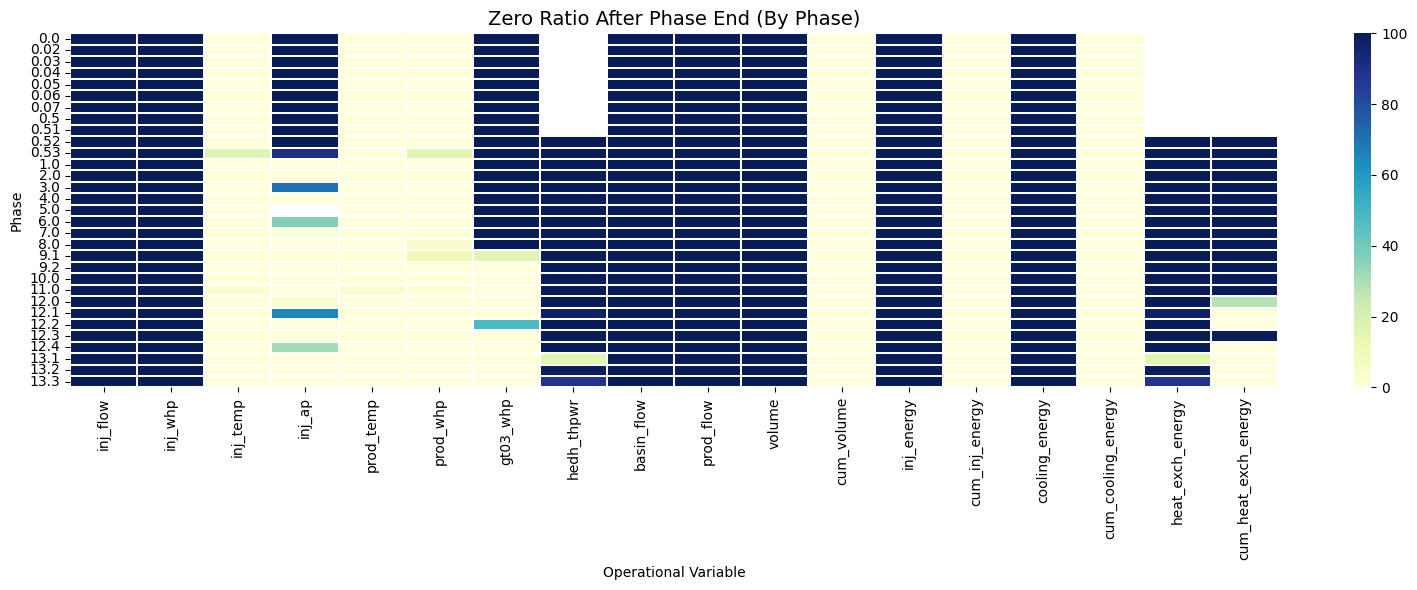

In [16]:
# Remove unnecessary columns before plotting
cols = [c for c in out.columns if c not in ["n_rows_after_end", "phase"]]

# Set 'phase' as the index and keep only numeric columns for the heatmap
df_hm = out.set_index("phase")[cols].astype(float)
plt.figure(figsize=(16, 6))

# Plot heatmap: color intensity represents % of zero values
sns.heatmap(
    df_hm,
    cmap="YlGnBu",          # yellow-green-blue color gradient
    vmin=0, vmax=100,       # scale range: 0% to 100%
    linewidths=0.2,         # thin lines between cells for clarity
)

# Add descriptive title and axis labels
plt.title("Zero Ratio After Phase End (By Phase)", fontsize=14)
plt.xlabel("Operational Variable")
plt.ylabel("Phase")
plt.tight_layout()
plt.show()



1. Dirty Data (completion, accuracy, validy, consistency)


  Table - `operational metrics`

    - Missing data (blank, null) values in the table -> completeness
    - Incorrect data type assigned to `recorded_at`, `phase_started_at`, `phase_production_ended_at`, `phase_ended_at`, `phase`. -> validity
    - Within each phase the time gap between each observation is not 5 minutes -> completeness & validity
    - check for outliers -> accuracy

  Table - `seismic events`

    - Incorrect data type assigned to `recorded_at`, `phase_started_at`, `phase_production_ended_at`, `phase_ended_at`, `phase` and `hourly_seismicity_rate` -> validity
    - redundant information of location column -> validity

2. Messy Data ( Structural Issue)

  Table - `seismic events` & `operational metrics`

    - Merge both data sets raise multiple problems like. -> (Structual Issue)
      - `seismic data` are random events, there might be multiple events in the five minutes time span -> issue with merging both datasets
      - Convert magnitude from continues to multi class.
    - Create new column with events occurred in `n` time span.  

### Data Quality Dimensions

- Completeness -> is data missing?
- Validity -> is data invalid?
- Accuracy -> data is valid but not accurate
- Consistency -> both valid and accurate but written differently

### Order of severity

Completeness <- Validity <- Accuracy <- Consistency

### Data Cleaning Order

1. Quality -> Completeness
2. Tidiness
3. Quality -> Validity
4. Quality -> Accuracy
5. Quality -> Consistency

#### Steps involved in Data cleaning
- Define (proposed solution)
- Code
- Test


`Note: create a copy of pandas dataframe before starting the cleaning process`

In [17]:
operational_data = operational_metrics.copy()
seismic_data = seismic_events.copy()

#### Completeness

In this section we're handling missing values. and it does depends on some validity issues so we're solving some of those first

**1. Setup**
- `Phase` type needed to be fixed
- Convert `recorded_at`, `phase_started_at`, `phase_production_ended_at`, `phase_ended_at` to datetime format.  
- Sort the dataset by `[phase, recorded_at]` to maintain time order.  

---
**2. Drop columns with missing >5%**

`hedh_thpwr`, `heat_exch_energy`, `cum_heat_exch_energy`


**3. Identify Short and Long Gaps (Internally)**
- Within each `phase`, calculate the time difference between consecutive records.  
- Classify each gap as:
  - **Short gap:** time difference ≤ 15 minutes  
  - **Long gap:** time difference > 15 minutes  
- These gap checks are done **internally** (no new columns created).

---

**4. Zero Out Non-Producing Periods**

When `is_producing == False`, set these operational columns to **0**:

`inj_flow, inj_whp, basin_flow, prod_flow, volume, inj_energy, cooling_energy`

---

**5. Fill Missing Values (Per Phase)**

Perform filling **only when `is_producing == True`**:

- **Short gaps:**  
  → Use **time interpolation** for smooth transitions.  

- **Long gaps:**  
  → If only **one row** is missing → use **MICE (Multiple Imputation by Chained Equations)**.  
  → If **multiple rows** are missing → use **forward fill** within the phase.

---

**6. Reapply Zero for Non-Producing Rows**

After filling, recheck and ensure all non-producing rows remain **0** in the operational columns.

---
**7. Reapply Zero for Non-Producing Rows**

After filling, recheck and ensure all non-producing rows remain **0** in the operational columns.

---
**8. Recalculate `prod_flow`**

`prod_flow` = `inj_flow` - `basin_flow`

---

**9. Recompute Cumulative Columns**

After filling, automatically **recalculate all `cum*` variables** (e.g., `cum_volume`, `cum_inj_energy`)  
as the cumulative sum of their corresponding base variables within each phase.


---

Fix `phase` variable type by changing it from float to Category. (**Validity**)

In [18]:
operational_data["phase"] = pd.Categorical(operational_data["phase"])

Fix `recorded_at`, `phase_started_at`, `phase_production_ended_at`, `phase_ended_at` variables type by changing it from **object** to **datetime**. (**Validity**)

In [19]:
def convert_time_columns(
    df: pd.DataFrame,
    time_cols: list[str] | None = None,
    errors: str = "coerce"
) -> pd.DataFrame:
    """
    Convert specified timestamp columns from object/string to datetime dtype.

    """

    if time_cols is None:
        time_cols = [
            "recorded_at",
            "phase_started_at",
            "phase_production_ended_at",
            "phase_ended_at",
        ]

    for col in time_cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors=errors)
        else:
            print(f"Column '{col}' not found — skipped.")

    return df

In [20]:
operational_data = convert_time_columns(operational_data)

Checking for missing values after production ended in each phase. Because if `is_producing == False`, then missing values will be tackled differently for some metrics.

In [21]:
def handle_missing_operational_data(
    df: pd.DataFrame,
    time_col: str = "recorded_at",
    phase_col: str = "phase",
    producing_col: str = "is_producing",
    # By default we DO NOT zero-out when not producing, since we now fill in both states.
    cols_zero_when_not_producing=(),
    short_gap_threshold_min: int = 15,
    drop_cols_if_missing_gt=("hedh_thpwr", "heat_exch_energy", "cum_heat_exch_energy"),
    drop_missing_threshold: float = 0.05,  # 5%
    random_state: int = 0,
    non_negative: bool = True,   # clip flows & cum_* to >= 0 if True
    verbose: bool = False,
):
    """
    Clean operational data per-phase with gap filling applied to ALL rows
    (both producing and non-producing):

      • Short gaps: time-based interpolation where both prev/next gaps <= threshold
      • Long gaps: bfill/ffill across time, then guarded IterativeImputer for residual NaNs
      • Flow consistency: prod_flow = inj_flow - basin_flow (then optional clip >= 0)
      • Optional zero-out when not producing
      • Recompute cum_* columns from their base columns per phase

    """
    d = df.copy()

    # ---- 1) Basic setup & typing
    d[time_col] = pd.to_datetime(d[time_col], errors="coerce")
    d = d.sort_values([phase_col, time_col]).reset_index(drop=True)

    # Ensure producing_col is strictly boolean (no truthy strings)
    if d[producing_col].dtype != bool:
        true_set = {"true", "1"}
        false_set = {"false", "0"}
        s = d[producing_col].astype(str).str.strip().str.lower()
        prod_bool = pd.Series(pd.NA, index=d.index, dtype="boolean")
        prod_bool[s.isin(true_set)] = True
        prod_bool[s.isin(false_set)] = False
        d[producing_col] = prod_bool.fillna(False).astype(bool)

    # Identify numeric columns, keys, and cumulative columns
    numeric_cols = d.select_dtypes(include=[np.number]).columns.tolist()
    key_cols = {phase_col, producing_col}
    cum_cols = [c for c in d.columns if c.lower().startswith("cum_")]
    dynamic_fill_cols = [c for c in numeric_cols if c not in key_cols and c not in cum_cols]

    # ---- 2) Drop columns that exceed missingness threshold (only from the given candidate list)
    dropped_columns = []
    if drop_cols_if_missing_gt:
        existing = [c for c in drop_cols_if_missing_gt if c in d.columns]
        if existing:
            miss_pct = d[existing].isna().mean()
            to_drop = miss_pct[miss_pct > drop_missing_threshold].index.tolist()
            if to_drop:
                dropped_columns = to_drop
                d = d.drop(columns=to_drop)
                dynamic_fill_cols = [c for c in dynamic_fill_cols if c not in dropped_columns]
                if verbose:
                    print(
                        "Dropped (>{:.1f}% missing): ".format(drop_missing_threshold * 100)
                        + ", ".join(f"{c} ({miss_pct[c]*100:.2f}%)" for c in to_drop)
                    )

    # ---- 3) Zero-out list (usually empty now)
    cols_zero_when_not_producing = [
        c for c in cols_zero_when_not_producing if c in d.columns and c in numeric_cols
    ]

    # ---- 4) If all three flow columns exist, exclude prod_flow from imputation inputs
    flow_relation_cols = ["inj_flow", "basin_flow", "prod_flow"]
    has_flows = all(col in d.columns for col in flow_relation_cols)
    if has_flows:
        dynamic_fill_cols = [c for c in dynamic_fill_cols if c != "prod_flow"]

    thr = pd.Timedelta(minutes=short_gap_threshold_min)

    def _fill_one_phase(phase_df: pd.DataFrame) -> pd.DataFrame:
        """
        Fill missing values within one phase for ALL rows:
          - Short-gap time interpolation where both prev & next gaps <= threshold.
          - Long-gap filling via bfill/ffill across time, then IterativeImputer for residual NaNs.
          - Enforce prod_flow relation, optionally clip to non-negative.
        """
        out = phase_df.copy()
        if out.empty:
            return out

        # --- Short-gap detection (independent of producing state)
        t = out[time_col]
        dt_prev = t.diff()           # gap to previous timestamp (Timedelta)
        dt_next = -t.diff(-1)        # gap to next timestamp (positive forward gap)
        short_mask_all = ((dt_prev <= thr) & (dt_next <= thr)).fillna(False)

        # --- Time interpolation for short-gap rows
        avail_fill_cols = [c for c in dynamic_fill_cols if c in out.columns]
        if short_mask_all.any() and avail_fill_cols:
            ts = out.set_index(time_col)
            ts[avail_fill_cols] = ts[avail_fill_cols].interpolate(
                method="time", limit_direction="both"
            )
            pos_rows = np.flatnonzero(short_mask_all.values)
            col_pos = [out.columns.get_loc(c) for c in avail_fill_cols]
            vals = ts[avail_fill_cols].to_numpy()
            out.iloc[pos_rows, col_pos] = vals[pos_rows, :]

        # --- Long-gap handling on ALL rows (not just producing)
        if avail_fill_cols:
            sub = out.loc[:, avail_fill_cols].copy()

            # Step 1: cheap time-wise fills
            sub = sub.bfill().ffill()

            # Step 2: If still missing, guarded IterativeImputer
            if sub.isna().any().any():
                informative_cols = sub.columns[sub.notna().any(axis=0)].tolist()
                all_nan_cols = [c for c in sub.columns if c not in informative_cols]

                # Policy for truly all-NaN columns: set to 0.0 to maintain shape
                if all_nan_cols:
                    sub.loc[:, all_nan_cols] = 0.0

                if len(informative_cols) >= 2:
                    imp = IterativeImputer(
                        random_state=random_state,
                        sample_posterior=False,
                        max_iter=25
                    )
                    imputed = imp.fit_transform(sub[informative_cols].values)
                    sub.loc[:, informative_cols] = imputed
                elif len(informative_cols) == 1:
                    col = informative_cols[0]
                    sub[col] = sub[col].fillna(0.0)

            # Assign back (same shape)
            out.loc[:, avail_fill_cols] = sub.values

        # --- Enforce flow relation after imputations
        if has_flows and all(c in out.columns for c in ["inj_flow", "basin_flow"]):
            valid_flow_mask = out[["inj_flow", "basin_flow"]].notna().all(axis=1)
            out.loc[valid_flow_mask, "prod_flow"] = (
                out.loc[valid_flow_mask, "inj_flow"] - out.loc[valid_flow_mask, "basin_flow"]
            )
            if non_negative:
                out["prod_flow"] = out["prod_flow"].clip(lower=0)

        return out

    # ---- 5) Apply per phase (avoid cross-phase leakage)
    d = d.groupby(phase_col, group_keys=False, observed=False).apply(_fill_one_phase)

    # ---- 6) Optional: zero-out when NOT producing (default OFF; enable by passing columns)
    if cols_zero_when_not_producing:
        not_prod = ~d[producing_col]
        if not_prod.any():
            zcols = [c for c in cols_zero_when_not_producing if c in d.columns]
            if zcols:
                d.loc[not_prod, zcols] = 0.0

    # ---- 7) Recompute all cum_* columns from their base columns per phase
    cum_cols = [c for c in cum_cols if c in d.columns]
    if cum_cols:
        # Map cum_* -> * (cum_heating -> heating)
        mapping = {c: c[len("cum_"):] for c in cum_cols if c.lower().startswith("cum_")}
        mapping = {cum: base for cum, base in mapping.items() if base in d.columns}

        if mapping:
            base_cols = list(set(mapping.values()))

            # Ensure base columns are numeric for cumsum
            for bc in base_cols:
                if not pd.api.types.is_numeric_dtype(d[bc]):
                    d[bc] = pd.to_numeric(d[bc], errors="coerce").fillna(0)

            d = d.sort_values([phase_col, time_col]).reset_index(drop=True)
            cums = d.groupby(phase_col, sort=False, observed=False)[base_cols].cumsum()

            for cum_col, base_col in mapping.items():
                d[cum_col] = cums[base_col]
                if non_negative:
                    d[cum_col] = d[cum_col].clip(lower=0)

    return d


In [22]:
operational_data_cleaned = handle_missing_operational_data(operational_data)

In [23]:
operational_data_cleaned.head()

,recorded_at,phase,inj_flow,inj_whp,inj_temp,inj_ap,prod_temp,prod_whp,gt03_whp,basin_flow,...,is_producing,phase_started_at,phase_production_ended_at,phase_ended_at,volume,cum_volume,inj_energy,cum_inj_energy,cooling_energy,cum_cooling_energy
0,2018-11-28 11:20:00,0.0,3.473958,29.742170,18.670664,0.0,22.161097,5.309335,0.0,0.0,...,True,2018-11-28 11:20:00,2018-11-28 14:15:00,2018-12-04 12:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,2018-11-28 11:25:00,0.0,25.510803,29.709707,11.027036,0.0,22.115342,5.307418,0.0,0.0,...,True,2018-11-28 11:20:00,2018-11-28 14:15:00,2018-12-04 12:00:00,2.125900,2.125900,0.001754,0.001754,0.306809,0.306809
2,2018-11-28 11:30:00,0.0,1.215181,29.675275,10.577293,0.0,22.089825,5.306586,0.0,0.0,...,True,2018-11-28 11:20:00,2018-11-28 14:15:00,2018-12-04 12:00:00,0.101265,2.227165,0.000083,0.001838,0.014663,0.321472
3,2018-11-28 11:35:00,0.0,8.490693,29.644622,10.619303,0.0,22.057563,5.306062,0.0,0.0,...,True,2018-11-28 11:20:00,2018-11-28 14:15:00,2018-12-04 12:00:00,0.707558,2.934723,0.000583,0.002421,0.102423,0.423895
4,2018-11-28 11:40:00,0.0,0.057919,29.614782,10.622052,0.0,22.148908,5.306007,0.0,0.0,...,True,2018-11-28 11:20:00,2018-11-28 14:15:00,2018-12-04 12:00:00,0.004827,2.939550,0.000004,0.002425,0.000699,0.424594


In [24]:
# check for null values if still exists

(operational_data_cleaned.isnull().sum() / len(operational_data_cleaned) * 100).sort_values(ascending=False)


,0
recorded_at,0.0
phase,0.0
inj_flow,0.0
inj_whp,0.0
inj_temp,0.0
inj_ap,0.0
prod_temp,0.0
prod_whp,0.0
gt03_whp,0.0
basin_flow,0.0


  Within each phase the time gap between each observation is not 5 minutes -> **completeness & validity**


#### **1. Setup**

- Work **per phase**; sort each phase by time.  
- Build a **complete 5-minute grid** between the first and last timestamp of each phase.  
- Reindex onto the 5-min grid → rows not present in the raw data become **gap rows**.

---

#### **2. Identify Column Groups**

Based on column names and function rules:

 **Gap-zeroed operational variables**
`inj_flow`, `basin_flow`, `prod_flow`, `inj_whp`, `gt03_whp`,  
`volume`, `inj_energy`, `cooling_energy`

**cum\_*** **columns**  
Forward-filled to maintain continuity  
(e.g., `cum_volume`, `cum_inj_energy`, ...)

**Boolean flag**
- `is_producing` (if present)

**Phase identity (copied from original phase)**
`phase`, `source`, `phase_started_at`,  
`phase_production_ended_at`, `phase_ended_at`

---

#### **3. Upsampling to a 5-Minute Grid (No Aggregation)**

For each phase:

- Create a complete **5-min DateTime index** covering the full phase.  
- Reindex the original data → **original rows stay; missing timestamps become gap rows**.

Handling on **gap rows**:

- `is_producing = False`  
- Operational variables listed in §2 → **set to 0**  
- Remaining numeric variables → **forward/backward filled only on gap rows**  
- **cum\_*** columns → forward-fill across the phase (maintain cumulative continuity)

---

#### **4. Data Point Indicator**

A helper column is added:

- `data_point_count = 1` for original rows  
- `data_point_count = 0` for upsampled gap rows  

Used later for validation or further processing.

---

#### **5. Recompute Derived Flow Variables**

If the required columns exist:

- `prod_flow = inj_flow − basin_flow`  
- If `non_negative=True`, clip negative values to zero.  

Applied **after** zero-gap filling to keep flows consistent.

---

#### **6. Post-Processing and Cleanup**

- Ensure `is_producing` is stored as a proper boolean.  
- Other numeric variables (not in special rule groups) may be clipped non-negative if enabled.  
- Restore the time column and sort the final output by **phase** and **time**.

---

In [25]:
def upsample_5min_within_phase_no_agg(
    df: pd.DataFrame,
    time_col: str = "recorded_at",
    phase_col: str = "phase",
    freq: str = "5min",
    non_negative: bool = True,
    zero_when_gap = ("inj_flow","basin_flow","prod_flow","inj_whp","gt03_whp", "volume","inj_energy","cooling_energy")

) -> pd.DataFrame:
    """
    Upsample to 5-min grid per phase without aggregation.

    Rules for rows introduced by upsampling (gaps):
      - is_producing = False (if the column exists)
      - selected operational variables = 0 (zero_when_gap)
      - remaining numeric variables: filled ONLY on gap rows via ffill/bfill
      - cum_* columns: ffill within phase for continuity
      - prod_flow = inj_flow - basin_flow when both present (clip >= 0 if non_negative)
    """
    if time_col not in df.columns:
        raise KeyError(f"Time column '{time_col}' not found")
    if phase_col not in df.columns:
        raise KeyError(f"Phase column '{phase_col}' not found")

    d = df.copy()
    d[time_col] = pd.to_datetime(d[time_col], errors="coerce")


    # Identify lists we’ll need
    all_cols = d.columns.tolist()
    has_is_prod = "is_producing" in all_cols
    zero_when_gap = [c for c in zero_when_gap if c in all_cols]
    cum_cols = [c for c in all_cols if c.lower().startswith("cum_")]
    # Numeric candidates for partial fill (we’ll filter per-phase later)
    # Note: we won't fill cum_* here; those are handled via ffill for all rows.
    results = []

    for phase_id, g in d.groupby(phase_col, observed=False):
        if g.empty:
            continue

        g = g.sort_values(time_col)
        g_idx = g.set_index(time_col)

        # Build complete 5-min index spanning this phase
        start = g_idx.index.min().floor(freq)
        end   = g_idx.index.max().ceil(freq)
        full_idx = pd.date_range(start=start, end=end, freq=freq)

        # Reindex to create gap rows (all-NaN initially)
        up = g_idx.reindex(full_idx)

        # Mark which rows are introduced gaps
        mask_gap = up.isna().all(axis=1)

        # Prepare helper count (0 for gaps, 1 for original rows)
        up["data_point_count"] = (~mask_gap).astype(int)

        # Carry over phase identity columns (copy first available value)
        id_cols = [c for c in ["phase","source","phase_started_at",
                               "phase_production_ended_at","phase_ended_at"]
                   if c in up.columns or c in g.columns]
        for col in id_cols:
            # If it was present in original, fill with per-phase first value
            if col in g.columns:
                up[col] = g[col].iloc[0]

        # cum_*: forward-fill across the whole phase (keep running totals continuous)
        for c in [c for c in cum_cols if c in up.columns]:
            up[c] = up[c].ffill()
            if non_negative:
                up[c] = up[c].clip(lower=0)

        # For gap rows:
        # - is_producing = False
        if has_is_prod:
            # First, keep original values where present; then set gaps to False
            # If original had non-boolean, coerce safely:
            up["is_producing"] = (
                up["is_producing"]
                .astype("boolean")
                .fillna(False)
                .astype(bool)
            )
            up.loc[mask_gap, "is_producing"] = False

        # - zero selected operational vars
        for c in zero_when_gap:
            if c in up.columns:
                up.loc[mask_gap, c] = 0

        # - ffill/bfill remaining numeric variables ONLY on gap rows
        numeric_cols = up.select_dtypes(include=[np.number, "boolean"]).columns.tolist()
        protected = set(["data_point_count", "is_producing"]) | set(zero_when_gap) | set(cum_cols)
        fill_cols = [c for c in numeric_cols if c not in protected and c in up.columns]

        if fill_cols:
            filled_all = up[fill_cols].ffill().bfill()
            up.loc[mask_gap, fill_cols] = filled_all.loc[mask_gap, fill_cols].values

        # After-fill: clip non-negative if desired (skip flags and cum_ already handled)
        if non_negative:
            nonneg_cols = [c for c in fill_cols if c != "is_producing"]
            for c in nonneg_cols:
                if c in up.columns and pd.api.types.is_numeric_dtype(up[c]):
                    up[c] = up[c].clip(lower=0)

        # Recompute prod_flow consistency whenever inputs exist
        if all(c in up.columns for c in ["inj_flow","basin_flow","prod_flow"]):
            valid = up[["inj_flow","basin_flow"]].notna().all(axis=1)
            up.loc[valid, "prod_flow"] = (up.loc[valid, "inj_flow"] - up.loc[valid, "basin_flow"])
            if non_negative:
                up["prod_flow"] = up["prod_flow"].clip(lower=0)

        # Bring back the time column
        up = up.reset_index().rename(columns={"index": time_col})
        # Attach phase id (if not present)
        if phase_col not in up.columns:
            up[phase_col] = phase_id

        results.append(up)

    if not results:
        return pd.DataFrame(columns=[time_col, phase_col])

    out = pd.concat(results, ignore_index=True).sort_values([phase_col, time_col]).reset_index(drop=True)

    # Ensure booleans are booleans
    if "is_producing" in out.columns:
        out["is_producing"] = out["is_producing"].fillna(False).astype(bool)

    return out


In [26]:
minute_data = upsample_5min_within_phase_no_agg(operational_data_cleaned)

### Validity:

  Table - `seismic events`

    - Convert data type into datetime of `recorded_at`, `phase_started_at`, `phase_production_ended_at`, `phase_ended_at`
    - Convert data type of `phase` into category
    - convert `hourly_seismicity_rate` to boolean
    - Remove location column to remove redundancy

In [27]:
seismic_data['phase'] = pd.Categorical(seismic_data['phase'])

In [28]:
seismic_data = convert_time_columns(seismic_data, time_cols = [
            "occurred_at",
            "phase_started_at",
            "phase_production_ended_at",
            "phase_ended_at",
        ])

In [29]:
seismic_data.drop(columns='location', inplace = True)

In [30]:
seismic_data['hourly_seismicity_rate'] = seismic_data['hourly_seismicity_rate'].astype('bool')

In [31]:
seismic_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 378 entries, 0 to 377
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   occurred_at                378 non-null    datetime64[ns]
 1   event_id                   378 non-null    int64         
 2   phase                      378 non-null    category      
 3   is_producing               378 non-null    bool          
 4   phase_started_at           378 non-null    datetime64[ns]
 5   phase_production_ended_at  378 non-null    datetime64[ns]
 6   phase_ended_at             378 non-null    datetime64[ns]
 7   pgv_max                    378 non-null    float64       
 8   magnitude                  378 non-null    float64       
 9   hourly_seismicity_rate     378 non-null    bool          
 10  distance_to_fault          378 non-null    float64       
 11  x                          378 non-null    float64       
 12  y       

## 2. Exploratory Data Analysis

#### Merge Both Datasets

In [32]:
def add_seismic_targets(minute_data: pd.DataFrame,
                        seismics: pd.DataFrame,
                        horizon_days: int = 7,
                        lookback_days: int = 7) -> pd.DataFrame:
    op = operational_data_cleaned.copy()
    ev = seismic_data.copy()

    # Normalize and sort timestamps
    # - recorded_at: timestamps at which we generate labels/features
    # - occurred_at: timestamps of seismic events
    op["recorded_at"] = pd.to_datetime(op["recorded_at"], errors="coerce")
    ev["occurred_at"] = pd.to_datetime(ev["occurred_at"], errors="coerce")
    op = op.dropna(subset=["recorded_at"]).sort_values("recorded_at").reset_index(drop=True)
    ev = ev.dropna(subset=["occurred_at"]).sort_values("occurred_at").reset_index(drop=True)

    # If no seismic events at all, return defaults
    if ev.empty:
        op["magnitude_bin_7days"] = 0
        op["no_event_7days"] = 1
        op["mag_lt_1_2_7days"] = 0
        op["mag_1_2_1_8_7days"] = 0
        op["mag_gt_1_8_7days"] = 0
        op["count_prev_7days"] = 0
        return op

    # Convert to numpy arrays (fast, vector-friendly)
    op_times = op["recorded_at"].to_numpy(dtype="datetime64[ns]")
    ev_times = ev["occurred_at"].to_numpy(dtype="datetime64[ns]")
    ev_mag = pd.to_numeric(ev["magnitude"], errors="coerce").to_numpy()

    # Keep only events with valid magnitudes
    valid = ~np.isnan(ev_mag)
    ev_times = ev_times[valid]
    ev_mag = ev_mag[valid]

    # If still empty after filtering invalid magnitudes, return defaults
    if ev_times.size == 0:
        op["magnitude_bin_7days"] = 0
        op["no_event_7days"] = 1
        op["mag_lt_1_2_7days"] = 0
        op["mag_1_2_1_8_7days"] = 0
        op["mag_gt_1_8_7days"] = 0
        op["count_prev_7days"] = 0
        return op

    # Prepare time deltas
    horizon_delta = np.timedelta64(horizon_days, 'D')
    lookback_delta = np.timedelta64(lookback_days, 'D')

    # FUTURE WINDOW: (t, t+7d]
    # - left: first event strictly after t (exclude events exactly at t)
    # - right: first event after t+7d (so we include events at exactly t+7d)
    left = np.searchsorted(ev_times, op_times, side="right")
    right = np.searchsorted(ev_times, op_times + horizon_delta, side="right")

    # PAST WINDOW: (t-7d, t]
    # - left_prev: first event strictly after t-7d (exclude events at exactly t-7d)
    # - right_prev: first event after t (so we include events at exactly t)
    left_prev = np.searchsorted(ev_times, op_times - lookback_delta, side="right")
    right_prev = np.searchsorted(ev_times, op_times, side="right")
    count_prev = (right_prev - left_prev).astype(int)

    # Compute max magnitude in each future window
    n = op_times.shape[0]
    max_mag_next = np.full(n, np.nan, dtype=float)

    # Loop because each row has its own window indices [left[i], right[i])
    for i in range(n):
        li, ri = left[i], right[i]
        if ri > li:  # there is at least one event in (t, t+7d]
            max_mag_next[i] = np.max(ev_mag[li:ri])

    # Bin the label by thresholds based on the future window's MAX magnitude:
    # 0: no event (no records in window)
    # 1: max < 1.2
    # 2: 1.2 <= max <= 1.8
    # 3: max > 1.8
    bins = np.zeros(n, dtype=int)
    has_event = ~np.isnan(max_mag_next)

    # < 1.2
    bins[np.where((has_event) & (max_mag_next < 1.2))] = 1
    # 1.2 - 1.8 (inclusive of 1.8)
    bins[np.where((has_event) & (max_mag_next >= 1.2) & (max_mag_next <= 1.8))] = 2
    # > 1.8
    bins[np.where((has_event) & (max_mag_next > 1.8))] = 3

    # Non-ordinal one-hot targets derived from the binned label
    no_event = (bins == 0).astype(int)
    lt_1_2 = (bins == 1).astype(int)
    btw_1_2_1_8 = (bins == 2).astype(int)
    gt_1_8 = (bins == 3).astype(int)

    # Attach outputs to the operation dataframe
    op["magnitude_bin_7days"] = bins
    op["no_event_7days"] = no_event
    op["mag_lt_1_2_7days"] = lt_1_2
    op["mag_1_2_1_8_7days"] = btw_1_2_1_8
    op["mag_gt_1_8_7days"] = gt_1_8
    op["count_prev_7days"] = count_prev

    return op

In [33]:
merged_minute = add_seismic_targets(minute_data, seismic_data, horizon_days=7, lookback_days=7)
merge_minute = merged_minute.sort_values("recorded_at")
merged_minute.to_csv('/content/drive/MyDrive/Data/merge_minute.csv', index=False)

In [34]:
merged_minute.head()

,recorded_at,phase,inj_flow,inj_whp,inj_temp,inj_ap,prod_temp,prod_whp,gt03_whp,basin_flow,...,inj_energy,cum_inj_energy,cooling_energy,cum_cooling_energy,magnitude_bin_7days,no_event_7days,mag_lt_1_2_7days,mag_1_2_1_8_7days,mag_gt_1_8_7days,count_prev_7days
0,2018-11-28 11:20:00,0.0,3.473958,29.742170,18.670664,0.0,22.161097,5.309335,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,1,0,1,0,0,0
1,2018-11-28 11:25:00,0.0,25.510803,29.709707,11.027036,0.0,22.115342,5.307418,0.0,0.0,...,0.001754,0.001754,0.306809,0.306809,1,0,1,0,0,0
2,2018-11-28 11:30:00,0.0,1.215181,29.675275,10.577293,0.0,22.089825,5.306586,0.0,0.0,...,0.000083,0.001838,0.014663,0.321472,1,0,1,0,0,0
3,2018-11-28 11:35:00,0.0,8.490693,29.644622,10.619303,0.0,22.057563,5.306062,0.0,0.0,...,0.000583,0.002421,0.102423,0.423895,1,0,1,0,0,0
4,2018-11-28 11:40:00,0.0,0.057919,29.614782,10.622052,0.0,22.148908,5.306007,0.0,0.0,...,0.000004,0.002425,0.000699,0.424594,1,0,1,0,0,0


Visualizations

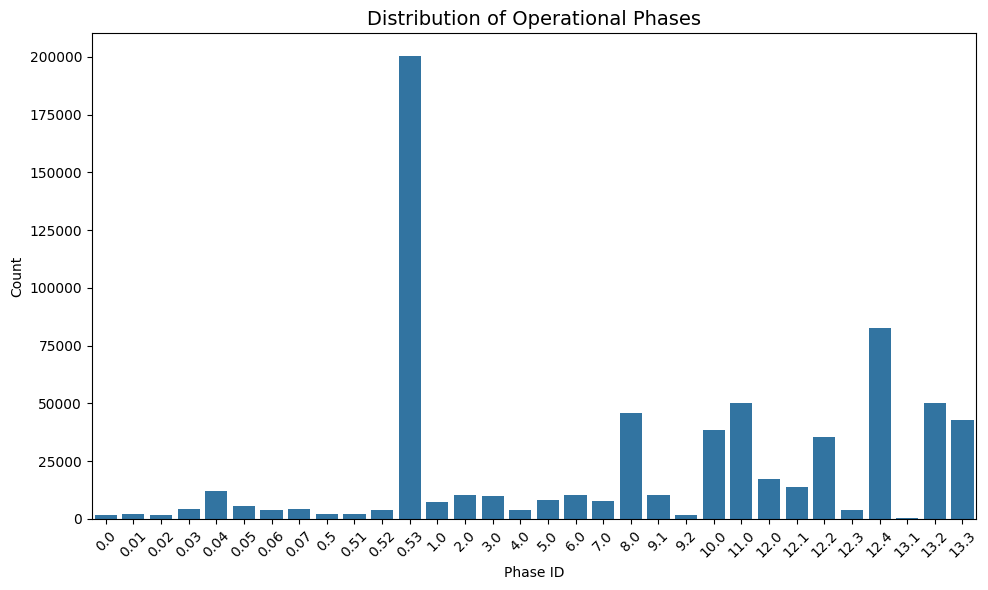

In [35]:
plt.figure(figsize=(10,6))
order = sorted(operational_data['phase'].dropna().unique())
sns.countplot(x='phase', data=operational_data, order=order)

plt.title("Distribution of Operational Phases", fontsize=14)
plt.xlabel("Phase ID")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

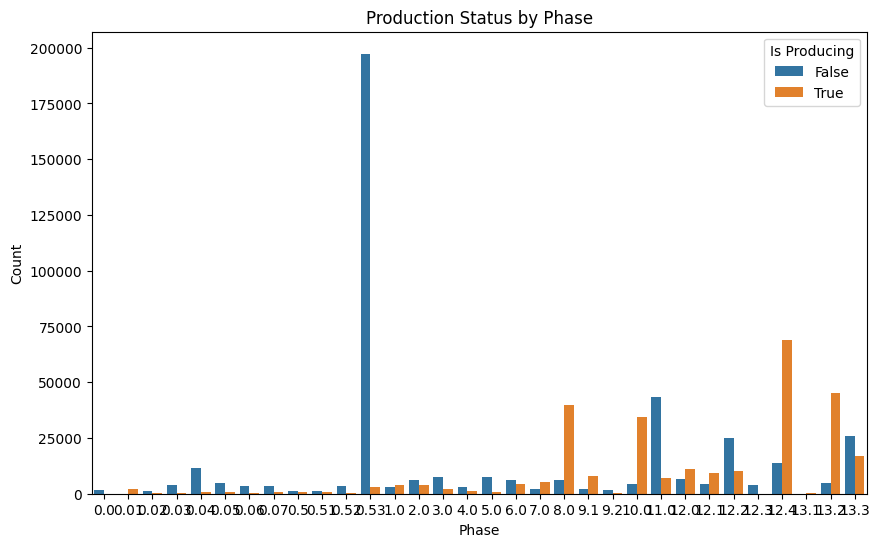

In [36]:
# 2. Production status by phase
plt.figure(figsize=(10,6))
sns.countplot(x='phase', hue='is_producing', data=operational_data_cleaned)
plt.title("Production Status by Phase")
plt.xlabel("Phase")
plt.ylabel("Count")
plt.legend(title="Is Producing")
plt.show()

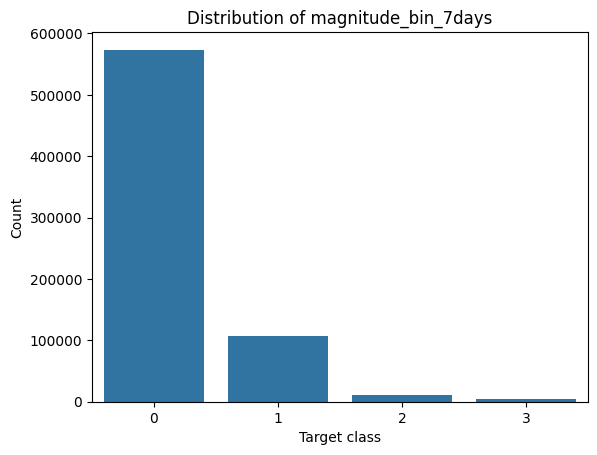

In [37]:
sns.countplot(data=merged_minute, x="magnitude_bin_7days")
plt.title("Distribution of magnitude_bin_7days")
plt.xlabel("Target class")
plt.ylabel("Count")
plt.show()

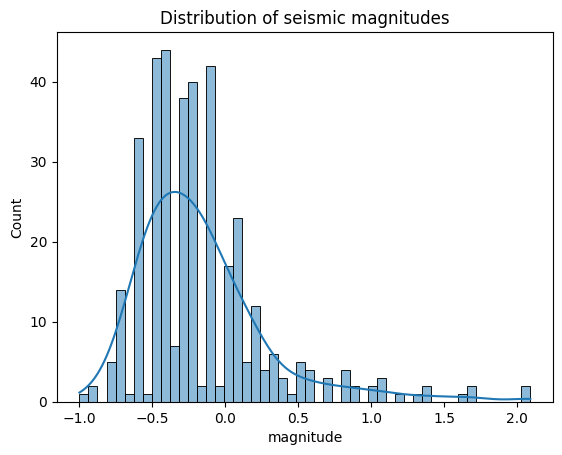

In [39]:
ev = seismic_data.copy()
ev["occurred_at"] = pd.to_datetime(ev["occurred_at"])
sns.histplot(ev["magnitude"], bins=50, kde=True)
plt.title("Distribution of seismic magnitudes")
plt.show()

Text(0.5, 1.0, 'Distribution of seismic counts in past 7 days')

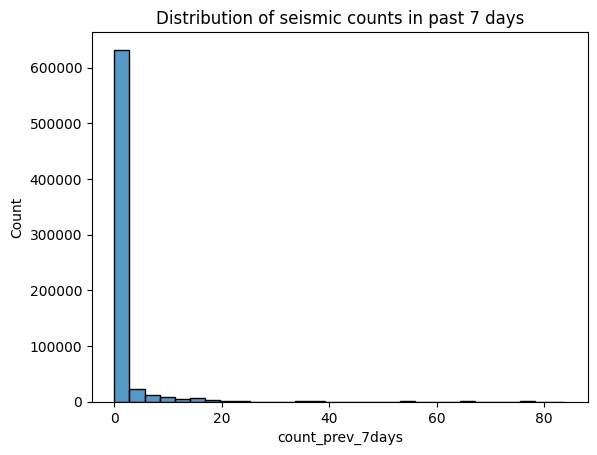

In [40]:
sns.histplot(merged_minute["count_prev_7days"], bins=30)
plt.title("Distribution of seismic counts in past 7 days")

In [41]:
# average count per bin
merged_minute.groupby("magnitude_bin_7days")["count_prev_7days"].mean()

,count_prev_7days
magnitude_bin_7days,
0,0.209479
1,3.922969
2,7.863090
3,32.260169


| **magnitude_bin_7days** | **Mean(count_prev_7days)** | **Interpretation**                                                                                                                         |
| ----------------------: | -------------------------: | ------------------------------------------------------------------------------------------------------------------------------------------ |
|        **0 (no event)** |                   **0.21** | On average, there is almost no seismic activity in the previous 7 days before periods with no upcoming events.                             |
|            **1 (<1.2)** |                   **3.92** | When a minor seismic event is about to occur, prior activity increases slightly — typically around 3–4 events in the previous week.        |
|         **2 (1.2–1.8)** |                   **7.86** | Moderate events are usually preceded by about 7–8 small tremors within the past 7 days.                                                    |
|            **3 (>1.8)** |                  **32.26** | Before strong seismic events, activity surges sharply — on average, more than 30 events occurred in the week leading up to the main event. |


In [42]:
merged_minute.isnull().sum()

,0
recorded_at,0
phase,0
inj_flow,0
inj_whp,0
inj_temp,0
inj_ap,0
prod_temp,0
prod_whp,0
gt03_whp,0
basin_flow,0


In [45]:
def plot_features_timeseries(
    df,
    time_col="recorded_at",
    features=None,
    resample_rule="1D",
    rolling_window=None,
    title_prefix="Feature",
    figsize_per_plot=(12, 2.8),
    sharex=True,
    shade_col="is_producing",
    shade_value=False,
    shade_color="lightcoral",
    shade_alpha=0.3,
    phase_col="phase",
    alt_colors=("tab:blue", "tab:orange"),
):
    d = df.copy()

    # Parse times and index
    d[time_col] = pd.to_datetime(d[time_col], errors="coerce")
    d = d.sort_values(time_col).set_index(time_col)

    # Determine feature list
    if features is None:
        features = d.select_dtypes(include=[np.number]).columns.tolist()

    # Keep only valid feature columns
    features = [c for c in features if c in d.columns]

    # Convert features to numeric
    d[features] = d[features].apply(pd.to_numeric, errors="coerce")

    # ---------------------------------------------------------
    # Resample: separate numeric & phase to avoid mean(category)
    # ---------------------------------------------------------
    if resample_rule:
        numeric_cols = features
        d_numeric = d[numeric_cols].resample(resample_rule).mean()

        if phase_col in d.columns:
            # forward fill discrete phase labels
            d_phase = d[[phase_col]].resample(resample_rule).ffill()
            d_feat = pd.concat([d_numeric, d_phase], axis=1)
        else:
            d_feat = d_numeric
    else:
        d_feat = d[features + ([phase_col] if phase_col in d.columns else [])]

    # Rolling smoothing
    if rolling_window:
        d_feat[features] = (
            d_feat[features].rolling(window=rolling_window, min_periods=1).mean()
        )

    # Keep only features that have actual data
    valid_features = [c for c in features if d_feat[c].notna().any()]
    d_feat = d_feat[valid_features + ([phase_col] if phase_col in d_feat.columns else [])]

    # ---------------------------------------------------------
    # Plot
    # ---------------------------------------------------------
    h = max(1, int(len(valid_features) * figsize_per_plot[1]))
    fig, axes = plt.subplots(
        nrows=len(valid_features),
        ncols=1,
        figsize=(figsize_per_plot[0], h),
        sharex=sharex,
    )
    if len(valid_features) == 1:
        axes = [axes]

    for ax, col in zip(axes, valid_features):

        # ---- segmented line color by phase ----
        if phase_col in d_feat.columns and d_feat[phase_col].notna().any():
            ph = d_feat[phase_col].astype(str).values
            t_idx = d_feat.index.values

            # find where phase changes
            change_idx = np.where(ph[1:] != ph[:-1])[0] + 1
            split_pts = np.r_[0, change_idx, len(ph)]

            # draw each continuous segment
            for seg in range(len(split_pts) - 1):
                s = split_pts[seg]
                e = split_pts[seg + 1]
                ax.plot(
                    d_feat.index[s:e],
                    d_feat[col].iloc[s:e],
                    linewidth=1.3,
                    color=alt_colors[seg % 2],
                )

        else:
            # fallback if no phase available
            ax.plot(d_feat.index, d_feat[col], linewidth=1.2)

        ax.set_title(f"{title_prefix}: {col}", fontsize=11)
        ax.set_ylabel(col)
        ax.grid(True, alpha=0.3)

        # ---- Shade regions where is_producing == False ----
        if shade_col in d.columns:
            mask = (d[shade_col] == shade_value).astype(int)
            change_pts = mask.diff().fillna(0).ne(0)

            starts = d.index[change_pts & (mask == 1)]
            ends   = d.index[change_pts.shift(-1).fillna(False) & (mask == 1)]

            if len(starts) > len(ends):
                ends = ends.append(pd.Index([d.index[-1]]))

            for s, e in zip(starts, ends):
                ax.axvspan(s, e, color=shade_color, alpha=shade_alpha)

    # Legend explaining alternating phase colors
    from matplotlib.patches import Patch
    leg_handles = [
        Patch(color=alt_colors[0], label="Phase t"),
        Patch(color=alt_colors[1], label="Phase t+1"),
        Patch(color=shade_color, alpha=shade_alpha, label=f"{shade_col}={shade_value}"),
    ]
    axes[0].legend(handles=leg_handles, fontsize=8, ncol=3, loc="upper left")

    axes[-1].set_xlabel("date")
    plt.tight_layout()
    plt.show()


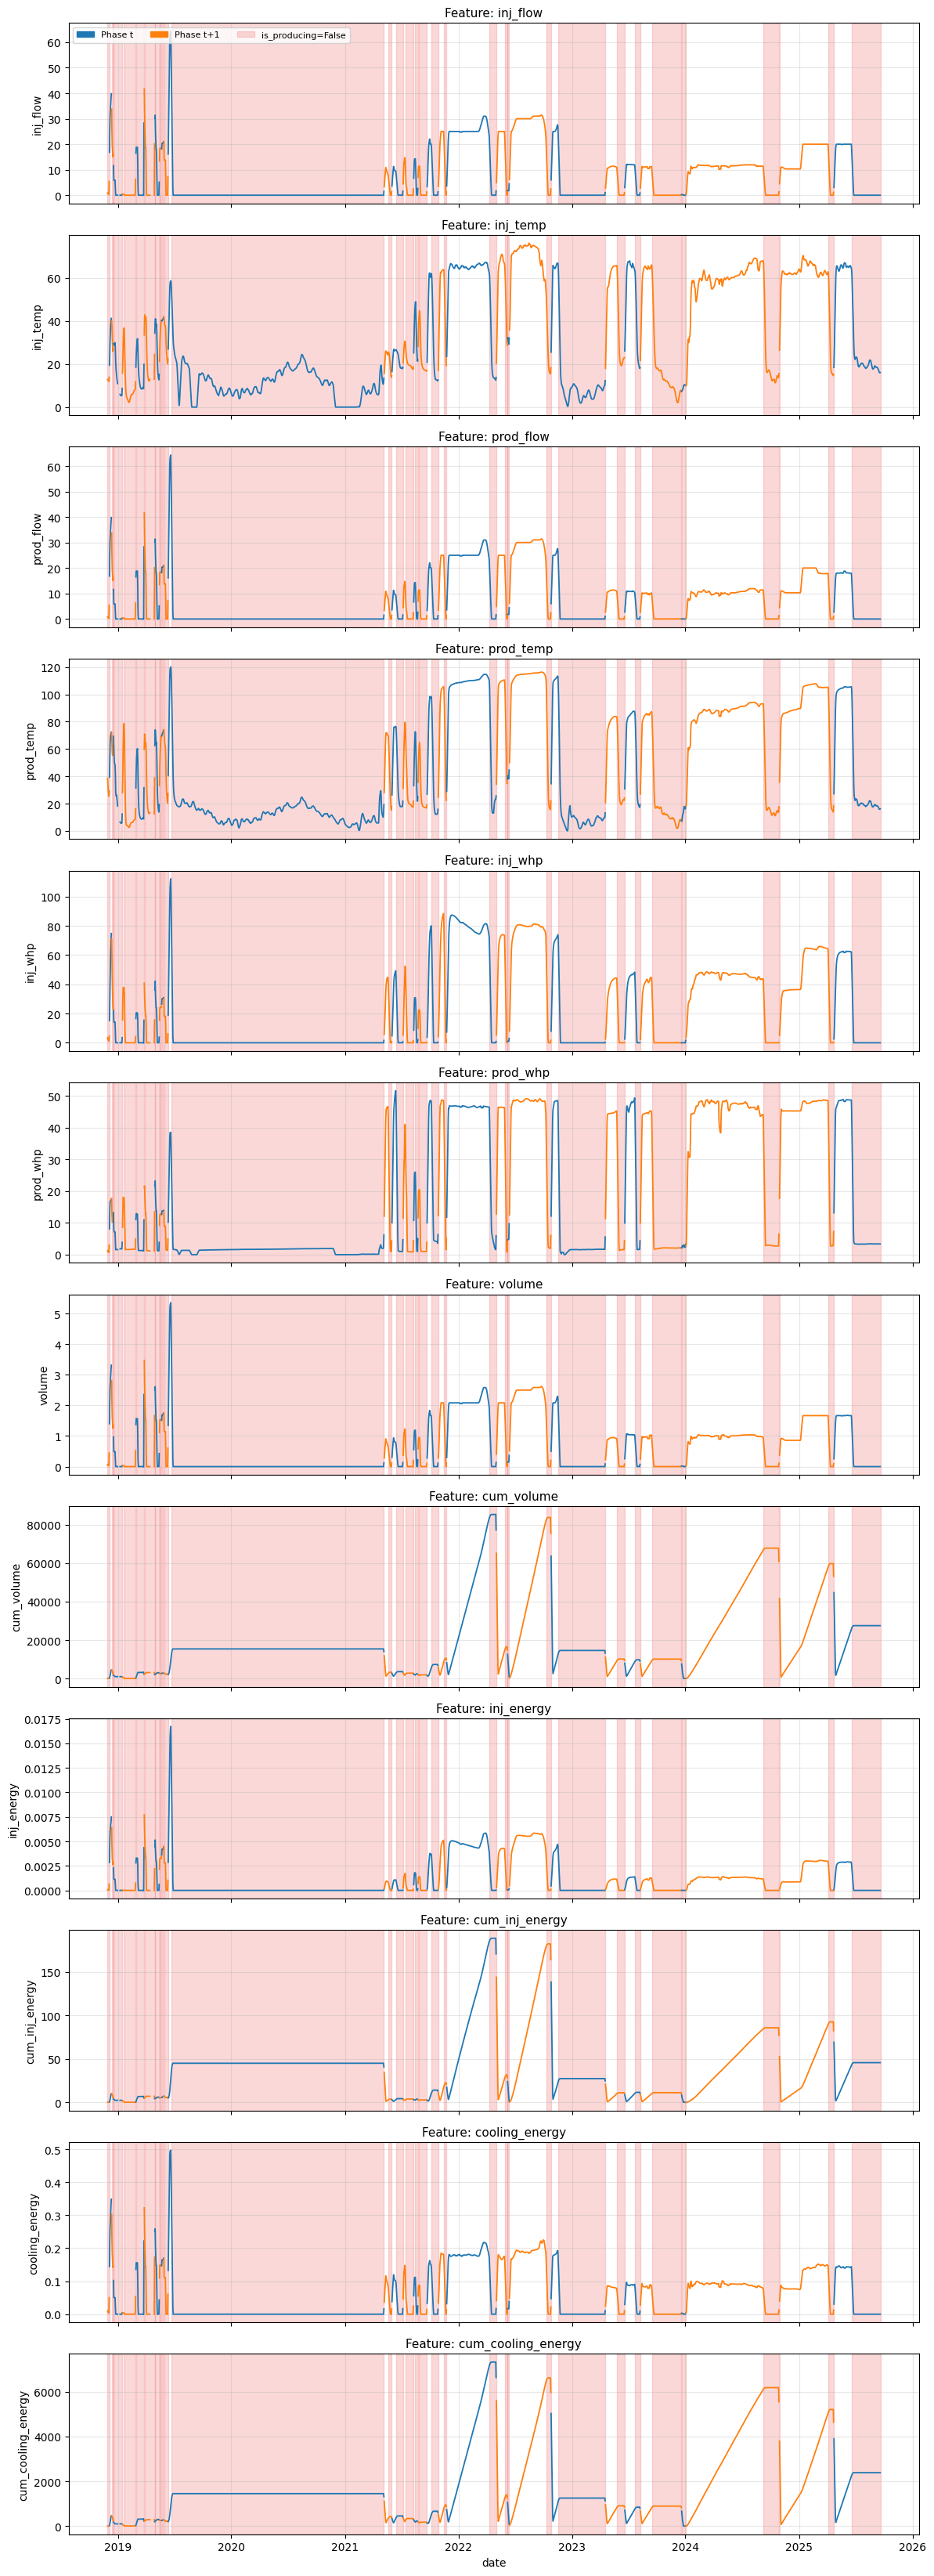

In [46]:
cols_to_plot = [
    "inj_flow","inj_temp","prod_flow","prod_temp","inj_whp","prod_whp",
    "volume","cum_volume","inj_energy","cum_inj_energy",
    "cooling_energy","cum_cooling_energy","heat_exch_energy","cum_heat_exch_energy"
]

# cols_to_plot = [
#     "inj_temp","prod_temp"
# ]

plot_features_timeseries(
    operational_data_cleaned,
    time_col="recorded_at",
    features=cols_to_plot,
    resample_rule="1D",
    rolling_window=7,
    title_prefix="Feature",
    shade_col="is_producing",
    shade_value=False,
    shade_color="lightcoral",
    shade_alpha=0.3,
    phase_col="phase",
    alt_colors=("tab:blue", "tab:orange"),  # chỉ 2 màu xen kẽ khi phase đổi
)

Before 2022 and after 2022, there were frequent shutdowns

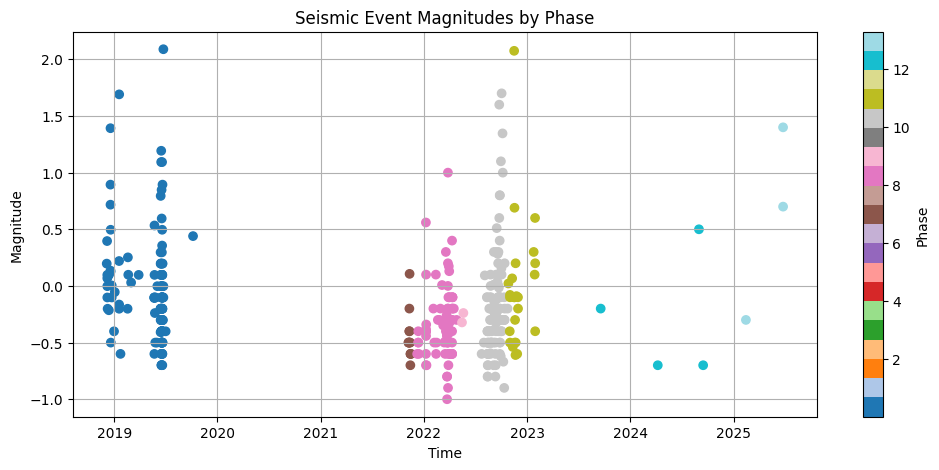

In [47]:
# Sort
seismic_data = seismic_data.sort_values("occurred_at")

# Plot
plt.figure(figsize=(12,5))
scatter = plt.scatter(
    seismic_data["occurred_at"],
    seismic_data["magnitude"],
    c=seismic_data["phase"],
    cmap="tab20",
)
plt.colorbar(scatter, label="Phase")
plt.xlabel("Time")
plt.ylabel("Magnitude")
plt.title("Seismic Event Magnitudes by Phase")
plt.grid(True)
plt.show()